In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
def build_merged_inference_df(
    datasets,
    *,
    fp_file_col: str = "file",
    fp_fold_prefix: str = "fold_",
    lab_file_col: str = "file",
    lab_L_prefix: str = "L_fold_",
    lab_a_prefix: str = "a_fold_",
    lab_b_prefix: str = "b_fold_",
):
    def _isic_id_from_path(p: str) -> str:
        return os.path.splitext(os.path.basename(str(p)))[0]

    def lab_to_ita(L, b):
        return np.arctan((L - 50.0) / b) * (180.0 / np.pi)

    dfs = []

    for dataset_name, fp_csv, lab_csv in datasets:
        fp_df = pd.read_csv(fp_csv)
        fp_df["isic_id"] = fp_df[fp_file_col].apply(_isic_id_from_path)

        fp_fold_cols = [c for c in fp_df.columns if c.startswith(fp_fold_prefix)]
        if len(fp_fold_cols) == 0:
            raise ValueError(f"[{dataset_name}] No fold columns found with prefix '{fp_fold_prefix}' in {fp_csv}")

        fp_df["fp_pred"] = fp_df[fp_fold_cols].mode(axis=1)[0]

        # remove fold columns
        fp_df = fp_df[["isic_id", "fp_pred"]]

        lab_df = pd.read_csv(lab_csv)
        lab_df["isic_id"] = lab_df[lab_file_col].apply(_isic_id_from_path)

        L_cols = [c for c in lab_df.columns if c.startswith(lab_L_prefix)]
        a_cols = [c for c in lab_df.columns if c.startswith(lab_a_prefix)]
        b_cols = [c for c in lab_df.columns if c.startswith(lab_b_prefix)]

        if len(L_cols) == 0 or len(a_cols) == 0 or len(b_cols) == 0:
            raise ValueError(
                f"[{dataset_name}] Missing Lab fold columns. "
                f"Found L={len(L_cols)}, a={len(a_cols)}, b={len(b_cols)} in {lab_csv}"
            )

        lab_df["L_pred"] = lab_df[L_cols].mean(axis=1)
        lab_df["a_pred"] = lab_df[a_cols].mean(axis=1)
        lab_df["b_pred"] = lab_df[b_cols].mean(axis=1)

        lab_df["ita_pred"] = lab_to_ita(lab_df["L_pred"].to_numpy(dtype=float), lab_df["b_pred"].to_numpy(dtype=float))

        merged = fp_df.merge(lab_df[["isic_id", "ita_pred"]], on="isic_id", how="left")        

        if dataset_name == "milk10k":
            # remove non-dermoscopic images from milk10k
            milk10k_metadata = pd.read_csv('inference_data/milk10k/MILK10k_Training_Metadata.csv')
            milk10k_metadata = milk10k_metadata[milk10k_metadata['image_type'] == 'dermoscopic']
            merged = merged[merged['isic_id'].isin(milk10k_metadata['isic_id'])]

        merged["dataset_name"] = dataset_name

        dfs.append(merged)

    return pd.concat(dfs, ignore_index=True)

In [58]:
datasets = [
    ("milk10k", "inference_results/infer=milk10k_model=finetune_mskcc_blur0.csv",
                "inference_results/infer=milk10k_model=finetune_mskcc_blur0_lab_lab.csv"),
    ("isic2020", "inference_results/infer=isic2020_model=finetune_mskcc_blur0.csv",
                "inference_results/infer=isic2020_model=finetune_mskcc_blur0_lab_lab.csv")]

inference_results_df = build_merged_inference_df(datasets)
display(inference_results_df.head())

mskcc_fp = pd.read_csv("test_results/finetune_mskcc_blur0.csv")
mskcc_lab = pd.read_csv("test_results/finetune_mskcc_blur0_lab.csv")

mskcc_fp["isic_id"] = mskcc_fp["file"].apply(lambda p: os.path.splitext(os.path.basename(str(p)))[0])
mskcc_lab["isic_id"] = mskcc_lab["file"].apply(lambda p: os.path.splitext(os.path.basename(str(p)))[0])

mskcc_new = mskcc_fp.merge(mskcc_lab[["isic_id", "ita_gt"]], on="isic_id", how="left")
mskcc_new["fp_pred"] = mskcc_new["fp"]
mskcc_new["ita_pred"] = mskcc_new["ita_gt"]
mskcc_new["dataset_name"] = "mskcc"

inference_results_df = pd.concat([inference_results_df, mskcc_new[inference_results_df.columns]], ignore_index=True)

print(f'Milk10k samples: {len(inference_results_df[inference_results_df["dataset_name"] == "milk10k"])}')
print(f'ISIC2020 samples: {len(inference_results_df[inference_results_df["dataset_name"] == "isic2020"])}')
print(f'MSKCC samples: {len(inference_results_df[inference_results_df["dataset_name"] == "mskcc"])}')

,isic_id,fp_pred,ita_pred,dataset_name
0,ISIC_4671410,1.0,8.635166,milk10k
1,ISIC_5371928,1.0,45.639779,milk10k
2,ISIC_3624913,2.0,34.475179,milk10k
3,ISIC_5186409,2.0,12.171621,milk10k
4,ISIC_1048297,1.0,43.995047,milk10k


Milk10k samples: 5240
ISIC2020 samples: 33126
MSKCC samples: 4879


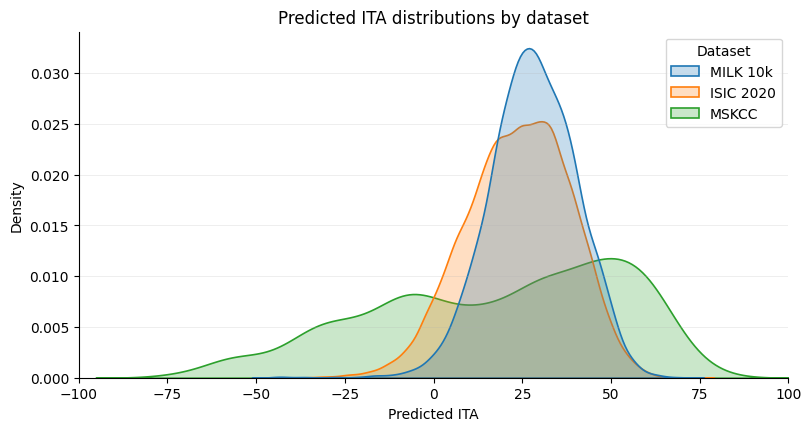

In [88]:
# Clean, paper-friendly KDE plot with a working legend
dfp = inference_results_df[["ita_pred", "dataset_name"]].dropna().copy()
dfp["ita_pred"] = dfp["ita_pred"].astype(float)

# rename dataset_name
dfp["dataset_name"] = dfp["dataset_name"].map({
    "milk10k": "MILK 10k",
    "isic2020": "ISIC 2020",
    "mskcc": "MSKCC"
})

# rename column itself
dfp = dfp.rename(columns={"ita_pred": "ITA"})
dfp = dfp.rename(columns={"dataset_name": "Dataset"})

# Robust x-limits so tails/outliers don't blow up the scale
x_lo, x_hi = -100, 100

fig, ax = plt.subplots(figsize=(8, 4.2), constrained_layout=True)

# Draw KDEs
sns.kdeplot(
    data=dfp,
    x="ITA",
    hue="Dataset",
    fill=True,
    common_norm=False,
    alpha=0.25,          # lighter fills read better with multiple datasets
    linewidth=1.2,
    bw_adjust=1.0,
    clip=(x_lo, x_hi),
    ax=ax,
)

# Improve readability
ax.set_xlim(x_lo, x_hi)
ax.set_title("Predicted ITA distributions by dataset")
ax.set_xlabel("Predicted ITA")
ax.set_ylabel("Density")

# Minimal grid (helps paper readability without looking “chart-y”)
ax.grid(True, axis="y", linewidth=0.6, alpha=0.25)

# despine
sns.despine(ax=ax)

plt.savefig("plots/lab_inference_result.pdf", bbox_inches='tight')

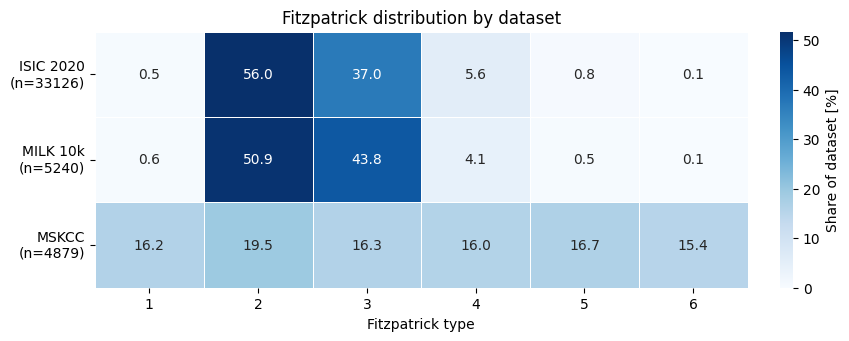

In [87]:
dfp = inference_results_df[["fp_pred", "dataset_name"]].dropna().copy()
dfp["fp_pred"] = dfp["fp_pred"].astype(int)
dfp["dataset_name"] = dfp["dataset_name"].astype(str)

# Rename datasets for display
name_map = {
    "isic2020": "ISIC 2020",
    "isic_2020": "ISIC 2020",
    "isic 2020": "ISIC 2020",
    "milk10k": "MILK 10k",
    "milk_10k": "MILK 10k",
    "mskcc": "MSKCC",
}
dfp["dataset_name"] = dfp["dataset_name"].map(lambda s: name_map.get(s, s))

# add one to fp
dfp["fp_pred"] += 1

fp_order = [1, 2, 3, 4, 5, 6]
if not set(fp_order).issubset(set(dfp["fp_pred"].unique())):
    fp_order = sorted(dfp["fp_pred"].unique().tolist())

ds_order = sorted(dfp["dataset_name"].unique().tolist())

counts = (
    dfp.groupby(["dataset_name", "fp_pred"])
       .size()
       .rename("count")
       .reset_index()
)

ds_sizes = dfp.groupby("dataset_name").size().rename("N").reset_index()
counts = counts.merge(ds_sizes, on="dataset_name", how="left")
counts["pct"] = 100.0 * counts["count"] / counts["N"]

heat = (
    counts.pivot(index="dataset_name", columns="fp_pred", values="pct")
          .reindex(index=ds_order, columns=fp_order)
          .fillna(0.0)
)

N_map = ds_sizes.set_index("dataset_name")["N"].to_dict()
yticklabels = [f"{ds}\n(n={int(N_map.get(ds, 0))})" for ds in heat.index]

fig_w = max(6.0, 0.9 * len(fp_order) + 3.0)
fig_h = max(2.2, 0.70 * len(ds_order) + 1.2)

fig, ax = plt.subplots(figsize=(fig_w, fig_h), constrained_layout=True)

sns.heatmap(
    heat,
    ax=ax,
    cmap="Blues",
    vmin=0,
    vmax=np.nanpercentile(heat.to_numpy(), 95) if heat.size else 1,
    annot=True,
    fmt=".1f",
    linewidths=0.6,
    linecolor="white",
    cbar_kws={"label": "Share of dataset [%]"},
)

ax.set_title("Fitzpatrick distribution by dataset")
ax.set_xlabel("Fitzpatrick type")
ax.set_ylabel("")
ax.set_yticklabels(yticklabels, rotation=0)

plt.savefig("plots/fp_inference_result.pdf", bbox_inches='tight')
